<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%201/Week_1_Lecture_7_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=nfEaPWZ_dRQ) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%201/DL4CV_Week01_Part07.pdf)

In [ ]:
# Week 1, Lecture 7: Image Sampling
from IPython.display import HTML, display

VIDEO_ID = "nfEaPWZ_dRQ"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

Watch on YouTube

# Week 1, Lecture 7: Image Sampling and Interpolation

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§1.7 Sampling and Interpolation**.

**Contents**
1. The cost of convolution: spatial vs frequency
2. Sub-sampling
3. Aliasing in 1D and the Nyquist rate
4. Aliasing in 2D: moire patterns
5. Anti-aliasing by pre-filtering
6. The Gaussian pyramid
7. Upsampling: interpolation as convolution
8. Interpolation in practice: nearest, bilinear, bicubic

## Review

The previous lecture showed that convolution in space is multiplication in frequency, $\mathcal{F}[g*h] =
\mathcal{F}[g]\mathcal{F}[h]$, which already hints at a cost saving for large kernels. This lecture pushes on the
sampling grid itself. Reducing resolution (sub-sampling) and increasing it (interpolation) are everywhere in
vision, from image pyramids to the strided and transposed convolutions inside networks, and both go wrong in
characteristic ways unless we respect the frequency content of the signal.

## Setup

Everything uses images bundled with `scikit-image`, so the notebook runs offline.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import data, util, color
from skimage.transform import resize

np.random.seed(0)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap']     = 'gray'
plt.rcParams['figure.dpi']     = 85

def load_gray(image, size=None):
    # float grayscale image, optionally resized to (size, size)
    g = color.rgb2gray(image) if image.ndim == 3 else util.img_as_float(image)
    if size is not None:
        g = resize(g, (size, size))
    return g

def show(ax, im, title='', spectrum=False):
    ax.imshow(im, cmap='magma' if spectrum else 'gray')
    ax.set_title(title); ax.axis('off')

## 1. The cost of convolution: spatial vs frequency

Direct convolution of an $N \times N$ image with a $k \times k$ kernel costs $O(N^2 k^2)$. The convolution
theorem replaces this with two FFTs and a pointwise product, costing about $O(N^2 \log N^2 + k^2 \log k^2)$,
which is independent of $k$ once the image is transformed. So the spatial route wins for tiny kernels (the FFT
has fixed overhead) and the frequency route wins as the kernel grows. The crossover is clear in the timings.

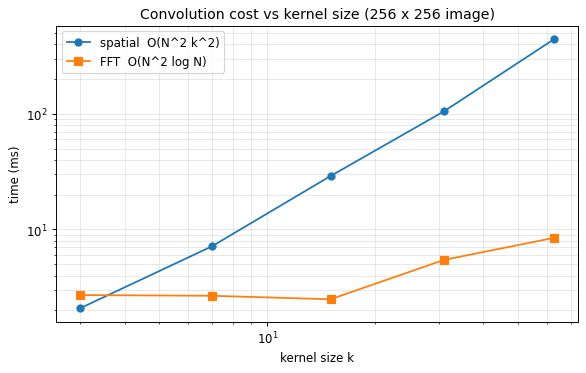

In [2]:
import time
from scipy.signal import convolve2d, fftconvolve

img = data.camera().astype(float)[::2, ::2]      # 256 x 256, keeps timing quick
fftconvolve(img, np.ones((3, 3)))                # warm-up so the first timed call is fair

ks, spatial_t, fft_t = [3, 7, 15, 31, 63], [], []
for k in ks:
    ker = np.ones((k, k)) / (k*k)
    t0 = time.perf_counter(); convolve2d(img, ker, mode='same', boundary='symm'); spatial_t.append(time.perf_counter()-t0)
    t0 = time.perf_counter(); fftconvolve(img, ker, mode='same');                 fft_t.append(time.perf_counter()-t0)

plt.figure(figsize=(7, 4.5))
plt.loglog(ks, np.array(spatial_t)*1e3, 'o-', label='spatial  O(N^2 k^2)')
plt.loglog(ks, np.array(fft_t)*1e3,     's-', label='FFT  O(N^2 log N)')
plt.xlabel('kernel size k'); plt.ylabel('time (ms)')
plt.title('Convolution cost vs kernel size (256 x 256 image)')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Sub-sampling

The simplest way to shrink an image is to throw away every other row and column. Repeating this gives the
$1/2$, $1/4$, $1/8$ versions below. The result quickly looks broken: thin structures flicker in and out and
edges turn jagged. The pixels we keep are not a fair summary of the ones we discard, and the next sections
explain why.

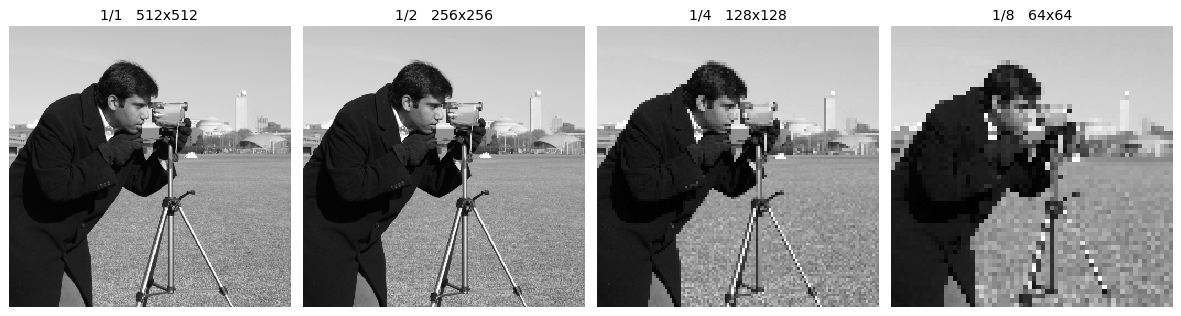

In [3]:
img = load_gray(data.camera())
fig, ax = plt.subplots(1, 4, figsize=(14, 4))
for a, s in zip(ax, [1, 2, 4, 8]):
    sub = img[::s, ::s]
    a.imshow(sub, interpolation='nearest')      # nearest keeps the true (aliased) pixels visible
    a.set_title(f'1/{s}   {sub.shape[0]}x{sub.shape[1]}'); a.axis('off')
plt.tight_layout(); plt.show()

## 3. Aliasing in 1D and the Nyquist rate

Aliasing happens when the sampling rate is too low for the detail present. A high-frequency sinusoid then
becomes indistinguishable from a lower-frequency one: both pass through the same samples. Shannon's sampling
theorem gives the safe rate, $f_s \ge 2 f_{max}$. Below it, a frequency $f$ masquerades as the alias
$|f - f_s\,\text{round}(f/f_s)|$. The same effect causes moire on striped shirts, the wagon-wheel illusion in
video, and disintegrating checkerboards in graphics.

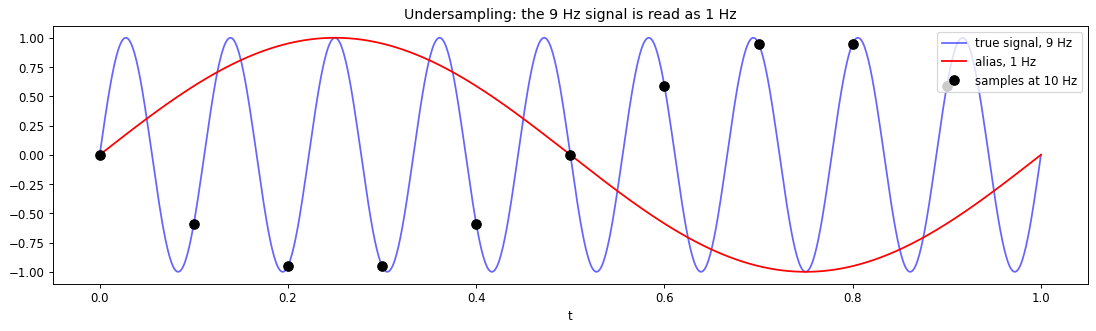

Nyquist needs fs >= 2*f = 18 Hz, but fs = 10 Hz  ->  alias at 1 Hz


In [4]:
f, fs = 9, 10                       # 9 Hz sampled at 10 Hz, well below 2*f = 18 Hz
f_alias = abs(f - fs*round(f/fs))   # = 1 Hz

t  = np.linspace(0, 1, 1000)
ts = np.arange(0, 1, 1/fs)
plt.figure(figsize=(13, 4))
plt.plot(t, np.sin(2*np.pi*f*t), 'b', alpha=0.6, label=f'true signal, {f} Hz')
plt.plot(t, np.sin(2*np.pi*f_alias*t), 'r', label=f'alias, {f_alias} Hz')
plt.plot(ts, np.sin(2*np.pi*f*ts), 'ko', ms=8, label=f'samples at {fs} Hz')
plt.legend(loc='upper right'); plt.xlabel('t')
plt.title('Undersampling: the 9 Hz signal is read as 1 Hz')
plt.tight_layout(); plt.show()

print(f'Nyquist needs fs >= 2*f = {2*f} Hz, but fs = {fs} Hz  ->  alias at {f_alias} Hz')

## 4. Aliasing in 2D: moire patterns

A **zone plate**, $\cos(\alpha r^2)$, has a frequency that grows with radius, so its outer rings sit above the
Nyquist limit of any coarse grid. Sub-sampling it without care folds those high frequencies back into spurious
low-frequency rings: a 2D alias, or **moire** pattern. The pattern below is entirely an artefact of sampling.

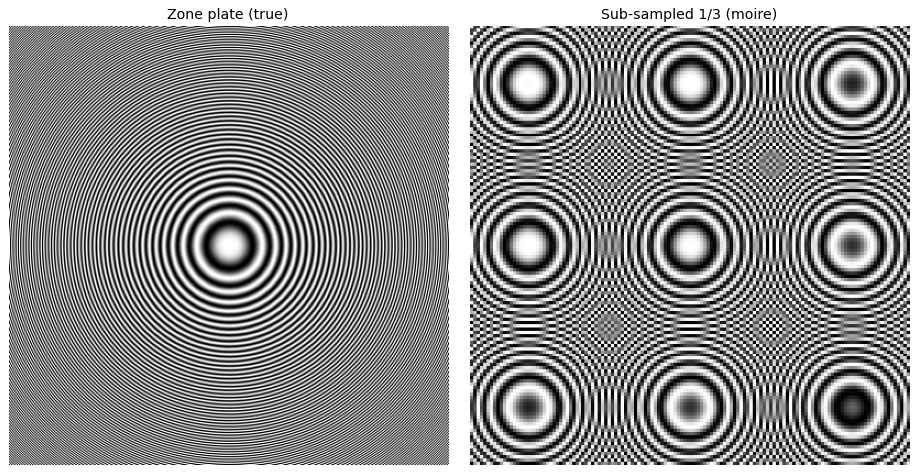

In [5]:
n = 400
y, x = np.mgrid[-n//2:n//2, -n//2:n//2]
zone = 0.5 + 0.5*np.cos((x**2 + y**2) * (np.pi*0.9/n))      # frequency rises with radius
s = 3
naive = resize(zone[::s, ::s], zone.shape, order=0, anti_aliasing=False)   # nearest-upsample to compare

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
show(ax[0], zone, 'Zone plate (true)')
show(ax[1], naive, f'Sub-sampled 1/{s} (moire)')
plt.tight_layout(); plt.show()

## 5. Anti-aliasing by pre-filtering

The fix is to remove the frequencies that cannot be represented before discarding samples. Blurring with a
Gaussian (a low-pass filter) first, then sub-sampling, keeps only content the coarse grid can hold, so the
moire disappears. This blur-then-sample order is the right way to downscale.

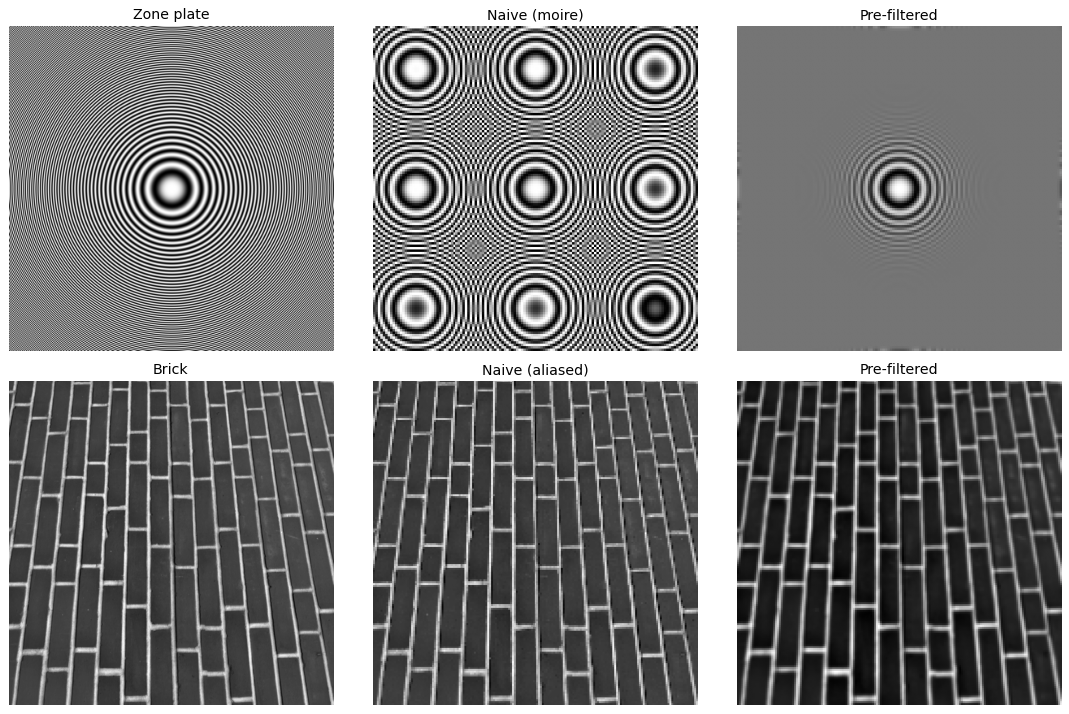

In [6]:
s = 3
def naive_sub(im):  return resize(im[::s, ::s], im.shape, order=0, anti_aliasing=False)
def anti_sub(im):   return resize(ndimage.gaussian_filter(im, 2)[::s, ::s], im.shape, order=0, anti_aliasing=False)

brick = load_gray(data.brick())
fig, ax = plt.subplots(2, 3, figsize=(13, 8.5))
show(ax[0, 0], zone, 'Zone plate');  show(ax[0, 1], naive_sub(zone), 'Naive (moire)');  show(ax[0, 2], anti_sub(zone), 'Pre-filtered')
show(ax[1, 0], brick, 'Brick');      show(ax[1, 1], naive_sub(brick), 'Naive (aliased)'); show(ax[1, 2], anti_sub(brick), 'Pre-filtered')
plt.tight_layout(); plt.show()

## 6. The Gaussian pyramid

Doing the safe downscale repeatedly, blur then sub-sample by two at each step, builds a **Gaussian pyramid**: a
stack of the same image at halving resolutions. It is a workhorse for multi-scale analysis, coarse-to-fine
search, and blending, and is the classical ancestor of the strided downsampling inside convolutional networks.

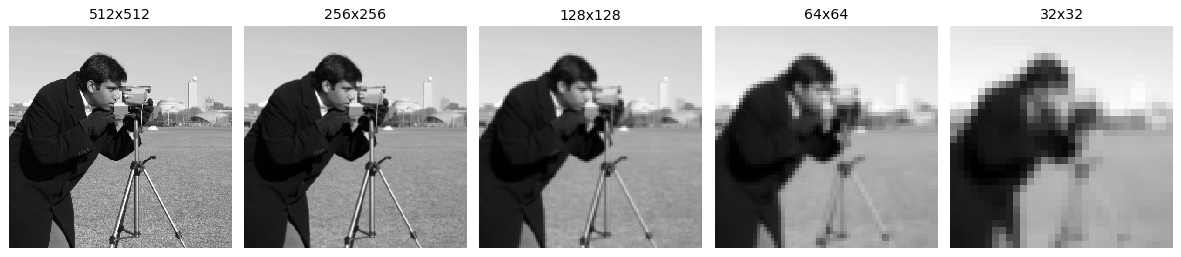

In [7]:
def gaussian_pyramid(im, levels):
    pyr, cur = [im], im
    for _ in range(levels):
        cur = ndimage.gaussian_filter(cur, 1)[::2, ::2]   # anti-alias, then drop every other sample
        pyr.append(cur)
    return pyr

pyr = gaussian_pyramid(load_gray(data.camera()), 4)
fig, ax = plt.subplots(1, len(pyr), figsize=(14, 4))
for a, level in zip(ax, pyr):
    a.imshow(level, interpolation='nearest'); a.set_title(f'{level.shape[0]}x{level.shape[1]}'); a.axis('off')
plt.tight_layout(); plt.show()

## 7. Upsampling: interpolation as convolution

Going the other way, to a higher resolution, we must invent samples between the known ones. Treat the samples as
impulses and convolve with an **interpolation kernel** $h$:

$$g(i) = \sum_{k} f(k)\, h(i - r k), \qquad r = \text{upsampling rate}$$

The kernel is the method. A **box** kernel copies the nearest sample (a staircase), a **tent** gives linear
interpolation (piecewise straight), a **cubic** gives a smooth curve, and the **sinc** is the ideal
band-limited reconstruction, though its slow decay produces ringing near edges.

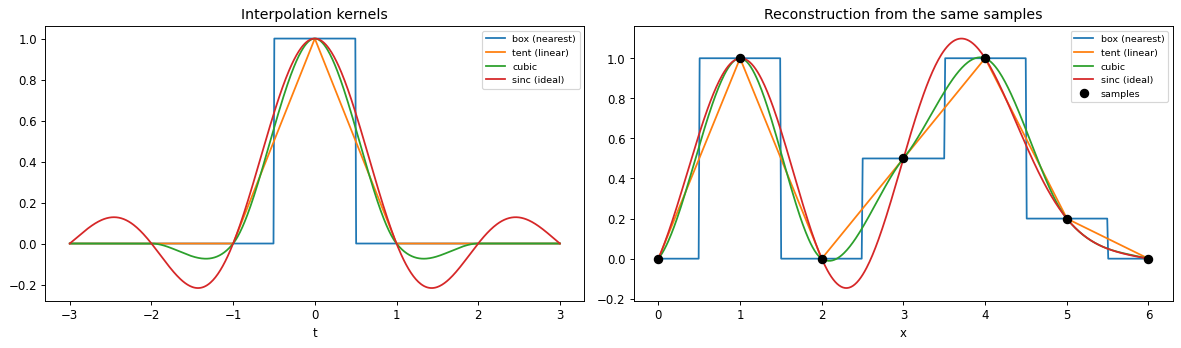

In [8]:
def k_box(t):   return (np.abs(t) <= 0.5).astype(float)
def k_tent(t):  return np.maximum(0, 1 - np.abs(t))
def k_cubic(t, a=-0.5):
    t = np.abs(t)
    return np.where(t <= 1, (a+2)*t**3 - (a+3)*t**2 + 1,
           np.where(t <  2, a*t**3 - 5*a*t**2 + 8*a*t - 4*a, 0.0))
def k_sinc(t):  return np.sinc(t)            # sin(pi t) / (pi t)

kernels = [('box (nearest)', k_box), ('tent (linear)', k_tent), ('cubic', k_cubic), ('sinc (ideal)', k_sinc)]
samples = np.array([0, 1, 0, 0.5, 1, 0.2, 0], float)

def reconstruct(x, kernel):
    return sum(s*kernel(x - i) for i, s in enumerate(samples))

t  = np.linspace(-3, 3, 600)
xx = np.linspace(0, len(samples)-1, 500)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for name, ker in kernels:
    ax[0].plot(t, ker(t), label=name)
    ax[1].plot(xx, reconstruct(xx, ker), label=name)
ax[0].set_title('Interpolation kernels'); ax[0].set_xlabel('t'); ax[0].legend(fontsize=8)
ax[1].plot(np.arange(len(samples)), samples, 'ko', ms=7, label='samples')
ax[1].set_title('Reconstruction from the same samples'); ax[1].set_xlabel('x'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8. Interpolation in practice: nearest, bilinear, bicubic

In 2D the same kernels give **nearest neighbour** (blocky), **bilinear** (smoother but soft), and **bicubic**
(sharper transitions from the cubic kernel). The zoomed crops make the trade-off visible: higher-order kernels
suppress the staircase artefacts at the cost of more computation.

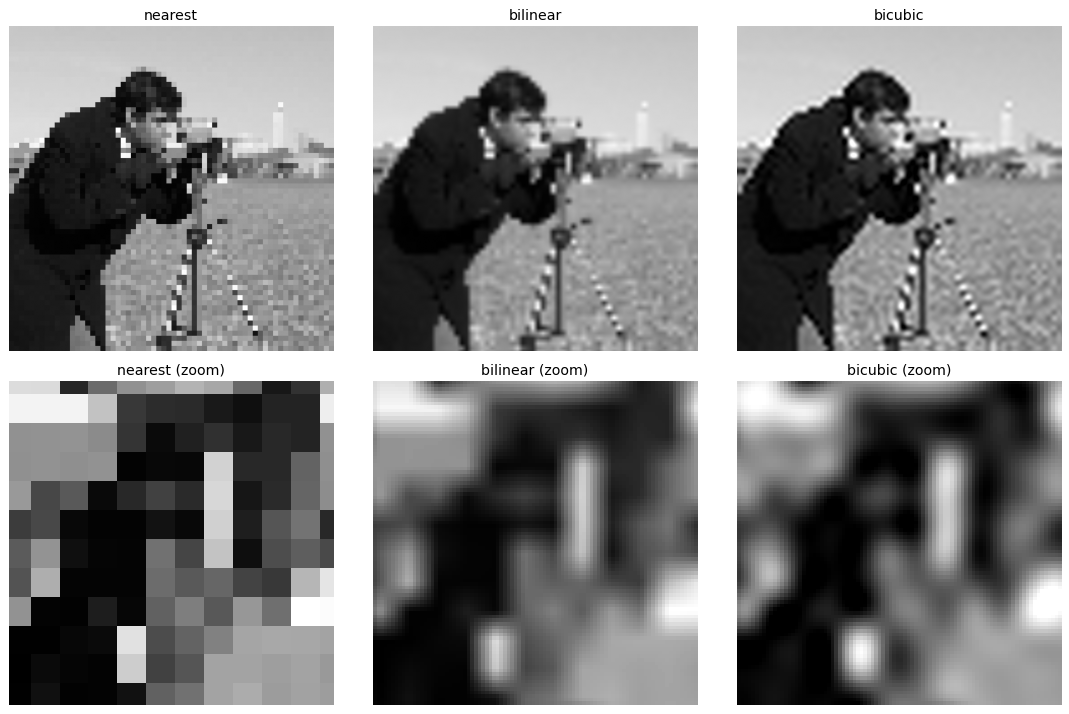

In [9]:
orig  = load_gray(data.camera())
small = orig[::8, ::8]                         # 64 x 64 source to upsample back to 512 x 512
methods = [('nearest', 0), ('bilinear', 1), ('bicubic', 3)]
ups = {name: resize(small, orig.shape, order=o, anti_aliasing=False) for name, o in methods}
cy, cx = 180, 250                              # a crop with fine detail (camera + tripod)

fig, ax = plt.subplots(2, 3, figsize=(13, 8.5))
for j, (name, _) in enumerate(methods):
    show(ax[0, j], ups[name], name)
    ax[1, j].imshow(ups[name][cy:cy+90, cx:cx+90], interpolation='nearest')
    ax[1, j].set_title(f'{name} (zoom)'); ax[1, j].axis('off')
plt.tight_layout(); plt.show()

---

## Summary

| Concept | Key takeaway |
|---|---|
| **Convolution cost** | Spatial is $O(N^2 k^2)$; the FFT route is about $O(N^2 \log N^2)$ and wins for large kernels |
| **Sub-sampling** | Dropping rows and columns discards high frequencies carelessly and looks broken |
| **Aliasing** | When $f_s < 2 f_{max}$ a high frequency masquerades as a lower one (moire, wagon-wheel) |
| **Nyquist rate** | Sample at $f_s \ge 2 f_{max}$ to represent a band-limited signal faithfully |
| **Anti-aliasing** | Low-pass (blur) before sub-sampling, so only representable content remains |
| **Gaussian pyramid** | Repeated blur-then-subsample-by-2; a multi-scale stack for coarse-to-fine vision |
| **Interpolation** | Upsampling convolves samples with a kernel $h$: $g(i)=\sum_k f(k)\,h(i-rk)$ |
| **Kernels** | Box gives nearest, tent gives linear, cubic gives smooth, sinc is ideal but rings |
| **Decimation** | Downsampling is also a convolution: $g(i)=\sum_k f(k)\,h(i-k/r)$ |

**Reading:** Szeliski, *Computer Vision: Algorithms and Applications*, Ch. 3 (3.5.1-3.5.2); Forsyth and Ponce,
*Computer Vision: A Modern Approach*, Ch. 7 (7.4).

**References:** S. Seitz; R. Urtasun (Toronto); N. Snavely (Cornell); B. Curless (UW).